In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from typing import Optional
from scipy.optimize import differential_evolution, shgo, dual_annealing
import time

In [2]:
# ----------------------------
# Constants (SI)
# ----------------------------

h = 6.62607015e-34
hbar = h / (2.0 * np.pi)
e = 1.602176634e-19
Phi0 = h / (2.0 * e)

# ----------------------------
# Nonlinear branch energy f(phi, phi_e) and analytic derivatives
# phi is dimensionless phase; phi_e is external flux through both loops in total in units of Phi0 (dimensionless)
# here, phi_e is a 2-element array: phi_e[0] is the external flux for the first branch, phi_e[1] is the external flux for the second branch
# ----------------------------
def f(phi, phi_e, EL, EJ):
    return 0.5 * EL * phi**2 - EJ * np.cos(phi - 2 * np.pi * phi_e[1]) - EJ * np.cos(phi + 2 * np.pi * phi_e[0])

def df(phi, phi_e, EL, EJ):
    return EL * phi + EJ * np.sin(phi - 2 * np.pi * phi_e[1]) + EJ * np.sin(phi + 2 * np.pi * phi_e[0])

def d2f(phi, phi_e, EL, EJ):
    return EL + EJ * np.cos(phi - 2 * np.pi * phi_e[1]) + EJ * np.cos(phi + 2 * np.pi * phi_e[0])

# ----------------------------
# Full constrained potential:
# phi_total = phi1 + phi2 + ... + phiN, eliminate phi1 = phi_total - sum(phi_extra)
# x = phi_extra = [phi2, phi3, ..., phiN] has length N-1
# phi_e_array has length N is the external flux for each branch
# ----------------------------
def U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    U = f(phi1, phi_e_array[0], EL, EJ)
    for i in range(x.size):
        U += f(x[i], phi_e_array[i + 1], EL, EJ)
    return U

def grad_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    df_phi1 = df(phi1, phi_e_array[0], EL, EJ)
    g = np.empty_like(x, dtype=float)
    for i in range(x.size):
        g[i] = -df_phi1 + df(x[i], phi_e_array[i + 1], EL, EJ)
    return g

def hess_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    a = d2f(phi1, phi_e_array[0], EL, EJ)  # all off-diagonal entries are a
    n = x.size
    H = np.full((n, n), a, dtype=float)
    for i in range(n):
        H[i, i] = a + d2f(x[i], phi_e_array[i + 1], EL, EJ)
    return H

# ----------------------------
# Minimization domain / periodicity for phase-like variables
# ----------------------------
phi_period = 2.0 * np.pi
phi_min_domain = -0.5 * phi_period
phi_max_domain =  0.5 * phi_period

# n_starts is the number of random restarts for global optimization; seed is for reproducibility
# phi_total is the coordinate we want to keep; x are the extra coordinates we minimize out
# phi_e_array is the external flux for each branch (length N_potential), this is fixed for the whole optimization
def minimize_phi_extra(phi_total, phi_e_array, x0, N_potential, EL, EJ, n_starts, seed, options = None):
    rng = np.random.default_rng(seed)
    n_extra = N_potential - 1

    # objective / derivatives for scipy
    def obj(x):
        return float(U_full(phi_total, x, phi_e_array, EL, EJ))

    def jac(x):
        return grad_U_full(phi_total, x, phi_e_array, EL, EJ)

    def hess(x):
        return hess_U_full(phi_total, x, phi_e_array, EL, EJ)

    best_x = None
    best_fun = np.inf

    # random-restart global search: sample x0 uniformly, run local minimizer, keep best
    for i in range(n_starts):
        if i == 0 and x0 is not None:
            x0 = np.array(x0, dtype=float)
        else:
            x0 = rng.uniform(phi_min_domain, phi_max_domain, size=n_extra)

        res = minimize(
            obj,
            x0,
            method="trust-exact",      # uses analytic jac + hess
            jac=jac,
            hess=hess,
            options=options,
        )

        if res.fun < best_fun:
            best_fun = float(res.fun)
            best_x = np.array(res.x, dtype=float)
    
    best_x = np.mod(best_x - phi_min_domain, phi_period) + phi_min_domain

    return best_x, best_fun

# ----------------------------
# Compute the effective 1D potential U_eff(phi_total) by minimizing out internal degrees of freedom
# 
# This performs a "Born-Oppenheimer" approximation: at each value of the total flux phi_total,
# we minimize over the internal flux distributions [phi2, phi3, ..., phiN] to find the 
# ground-state energy. This reduces the N-dimensional problem to an effective 1D problem.
#
# The result U_eff(phi_total) is the potential energy surface that the system sees when 
# the internal coordinates have relaxed to their optimal configuration.
# ----------------------------

# phi_grid is the array of total flux values we want to evaluate U_eff at
# phi_e_array is the external flux for each branch (length N_potential), this is fixed
# N_potential is the total number of branches (including phi1), EL and EJ are the energy scales
def compute_Ueff(phi_grid, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=None):
    # Pre-allocate arrays to store results at each grid point
    Ueff = np.empty_like(phi_grid, dtype=float)                      # effective 1D potential energy
    x_star = np.empty((phi_grid.size, N_potential - 1), dtype=float) # optimal internal coordinates. Row i is the optimal [phi2, phi3, ..., phiN] for phi_total = phi_grid[i]
    
    # Warm-start optimization: use previous point's solution as initial guess for next point
    # This helps the optimizer follow the same energy minimum branch smoothly along phi_total
    x_prev = None
    
    for i, phi_total in enumerate(phi_grid):
        # Minimize U_full over internal coordinates x = [phi2, ..., phiN] at fixed phi_total
        x_opt, U_opt = minimize_phi_extra(phi_total, phi_e_array, x_prev, N_potential, EL, EJ, n_starts, seed, options=options)
        
        # Store the minimized energy and optimal internal coordinates
        x_star[i, :] = x_opt   # optimal flux distribution at this phi_total
        Ueff[i] = U_opt        # minimum energy = effective potential
        
        # Use this solution to initialize the next optimization step (warm start)
        x_prev = x_opt
    
    return Ueff, x_star

# ----------------------------
# Diagonalize the 1D quantum Hamiltonian H = 4*EC*n^2 + U_eff(phi) using finite differences
#
# The number operator n = -i*d/dphi becomes a discretized derivative, so the kinetic energy
# 4*EC*n^2 = -4*EC*d²/dphi² is represented by a finite-difference Laplacian matrix.
#
# We impose Dirichlet (zero) boundary conditions: ψ(phi_min) = ψ(phi_max) = 0
# This is appropriate when U_eff → ∞ at the boundaries, confining the wavefunction.
#
# order=3: Standard 3-point stencil (2nd-order accurate), gives tridiagonal matrix
# order=5: Higher-accuracy 5-point stencil (4th-order accurate), gives pentadiagonal matrix
# ----------------------------
def diagonalize_fd(phi_grid, Ueff, EC, n_levels, order):
    dphi = phi_grid[1] - phi_grid[0]  # uniform grid spacing
    
    # Enforce Dirichlet (zero) boundary conditions by excluding boundary points
    # We only solve for the wavefunction at interior points: phi_grid[1:-1]
    U_in = Ueff[1:-1]  # potential on interior points, excludes the two boundaries where ψ=0
    N = U_in.size      # number of interior points
    
    # KE and U_in properly account for the potential = 0 at boundaries
    if order == 3: 
        # Standard 3-point centered difference: ψ'' ≈ (ψ_{i-1} - 2ψ_i + ψ_{i+1})/dphi²
        # Kinetic energy: -4*EC*d²/dphi² → diagonal: +8*EC/dphi², off-diag: -4*EC/dphi²
        main = (8.0 * EC / dphi**2) + U_in      # diagonal: kinetic + potential
        off1 = (-4.0 * EC / dphi**2) * np.ones(N - 1)  # nearest-neighbor coupling due to kinetic energy
        H = diags([off1, main, off1], offsets=[-1, 0, 1], format="csc")
    
    elif order == 5:
        # 5-point stencil for higher accuracy (4th-order in interior):
        # ψ'' ≈ (-ψ_{i+2} + 16ψ_{i+1} - 30ψ_i + 16ψ_{i-1} - ψ_{i-2}) / (12*dphi²)
        # Multiply by -4*EC to get kinetic energy operator coefficients
        c0 = (10.0 * EC / dphi**2)             # diagonal (note: 30/12 * 4 = 10)
        c1 = (-16.0 * EC / (3.0 * dphi**2))    # ±1 neighbors (16/12 * 4 = 16/3)
        c2 = (1.0 * EC / (3.0 * dphi**2))      # ±2 neighbors (1/12 * 4 = 1/3)
        
        main = c0 + U_in                       # diagonal: kinetic + potential
        off1 = c1 * np.ones(N - 1)            # nearest neighbors
        off2 = c2 * np.ones(N - 2)            # next-nearest neighbors
        H = diags([off2, off1, main, off1, off2], offsets=[-2, -1, 0, 1, 2], format="csc")
    
    else:
        raise ValueError("order must be 3 or 5")
    
    # Find the lowest n_levels eigenstates using sparse eigenvalue solver
    # "SA" = smallest algebraic eigenvalues (ground state and low-lying excited states)
    evals, evecs = eigsh(H, k=n_levels, which="SA")
    
    # Sort eigenvalues in ascending order (should already be sorted, but ensure it)
    idx = np.argsort(evals)
    
    return evals[idx], evecs[:, idx]

def full_analysis(phi_total_mag, N_opt, N_fine, phi_e_array, N_potential, EL, EJ, EC, n_levels, order: Optional[int] = 5, n_starts: Optional[int] = 3, seed: Optional[int] = 0, options: Optional[dict] = {"maxiter": 200, "gtol": 1e-8}):

    # coarse grid for minimizing out extra coordinates (expensive)
    phi_total_min = -phi_total_mag * 2 * np.pi
    phi_total_max =  phi_total_mag * 2 * np.pi
    phi_opt = np.linspace(phi_total_min, phi_total_max, N_opt)

    Ueff_opt, x_star = compute_Ueff(phi_opt, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=options)

    # spline onto a finer grid for diagonalization (cheap)
    phi_fine = np.linspace(phi_total_min, phi_total_max, N_fine)
    U_spline = CubicSpline(phi_opt, Ueff_opt, bc_type="natural")
    Ueff_fine = U_spline(phi_fine)

    # diagonalize with non-periodic boundaries
    E_GHz, V = diagonalize_fd(phi_fine, Ueff_fine, EC, n_levels, order)

    return {'phi_fine' : phi_fine, 'Ueff_fine' : Ueff_fine, 'phi_opt' : phi_opt, 'Ueff_opt': Ueff_opt, 'E_GHz' : E_GHz, 'V' : V, 'N_opt' : N_opt, 'N_fine' : N_fine, 'phi_total_min' : phi_total_min, 'phi_total_max' : phi_total_max, 'x_star' : x_star}
    

In [3]:
# ----------------------------
# Circuit parameters
# ----------------------------
# C = 60e-15
# L = 10e-9

# EJ = 12.0 # in GHz
# EL = ((hbar / (2.0 * e)) ** 2 / L) / (h * 1e9)  # convert to GHz
# EC = (e**2 / (2.0 * C))/(h * 1e9)  # convert to GHz

N_potential = 3  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 3.333

EC = 0.1
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target
EJ = EL / EL_EJ_ratio

result = full_analysis(
    phi_total_mag=2, 
    N_opt=20, 
    N_fine=4000, 
    phi_e_array=np.array([[0.25, 0.25], [0.25, 0.25], [0.25, 0.25]], dtype=float), 
    N_potential=N_potential, 
    EL=EL, 
    EJ=EJ, 
    EC=EC, 
    n_levels=3, 
    order=5, 
    n_starts=1, 
    seed=0,
    options={"maxiter": 100, "gtol": 1e-7}
)

E_GHz = result['E_GHz']

print("Lowest energy levels (GHz):")
for i, Ei in enumerate(E_GHz):
    print(f"  E[{i}] = {Ei:.9f} GHz")

print("\nTransition frequencies (GHz):")
for i in range(1, len(E_GHz)):
    print(f"  f_{i}{i-1} = {E_GHz[i] - E_GHz[i-1]:.9f} GHz")

print("\nAnharmonicity (GHz):")
print(f"  α = {E_GHz[2] - 2*E_GHz[1] + E_GHz[0]:.9f} GHz")


Lowest energy levels (GHz):
  E[0] = 3.249948254 GHz
  E[1] = 9.749965107 GHz
  E[2] = 16.249981658 GHz

Transition frequencies (GHz):
  f_10 = 6.500016852 GHz
  f_21 = 6.500016551 GHz

Anharmonicity (GHz):
  α = -0.000000301 GHz


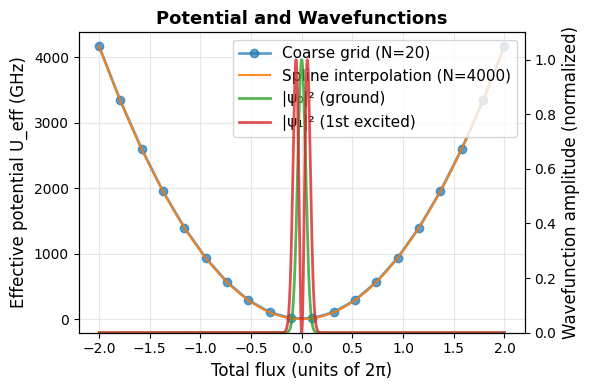

In [4]:
phi_opt = result['phi_opt']
Ueff_opt = result['Ueff_opt']
N_opt = result['N_opt']
phi_fine = result['phi_fine']
Ueff_fine = result['Ueff_fine']
N_fine = result['N_fine']
V = result['V']

# Plot the raw coarse data and the fine spline interpolation with wavefunctions
fig, ax = plt.subplots(figsize=(6, 4))

# Plot raw coarse grid data
ax.plot(phi_opt / (2*np.pi), Ueff_opt, 'o-', linewidth=2, markersize=6, 
        label=f'Coarse grid (N={N_opt})', color='C0', alpha=0.7)

# Plot fine spline interpolation
ax.plot(phi_fine / (2*np.pi), Ueff_fine, '-', linewidth=1.5, 
        label=f'Spline interpolation (N={N_fine})', color='C1', alpha=0.9)

ax.set_xlabel('Total flux (units of 2π)', fontsize=12)
ax.set_ylabel('Effective potential U_eff (GHz)', fontsize=12)
ax.set_title('Potential and Wavefunctions', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for wavefunctions
ax2 = ax.twinx()

# Interior grid points where wavefunctions are defined (exclude boundaries)
phi_interior = phi_fine[1:-1]

# Plot ground state wavefunction (|ψ₀|²)
psi0_sq = V[:, 0]**2
psi0_sq_normalized = psi0_sq / np.max(psi0_sq)  # normalize for visualization
ax2.plot(phi_interior / (2*np.pi), psi0_sq_normalized, '-', linewidth=2, 
         label='|ψ₀|² (ground)', color='C2', alpha=0.8)

# Plot first excited state wavefunction (|ψ₁|²)
psi1_sq = V[:, 1]**2
psi1_sq_normalized = psi1_sq / np.max(psi1_sq)  # normalize for visualization
ax2.plot(phi_interior / (2*np.pi), psi1_sq_normalized, '-', linewidth=2, 
         label='|ψ₁|² (1st excited)', color='C3', alpha=0.8)

ax2.set_ylabel('Wavefunction amplitude (normalized)', fontsize=12)
ax2.set_ylim(0, 1.1)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

In [5]:
print(f"\nCharging energy EC = {EC:.3f} GHz")
print(f"Inductive energy EL = {EL:.3f} GHz")
print(f"Josephson energy EJ = {EJ:.3f} GHz")


Charging energy EC = 0.100 GHz
Inductive energy EL = 158.438 GHz
Josephson energy EJ = 47.536 GHz


Running flux sweep...
  Completed 10/30 flux points
  Completed 20/30 flux points
  Completed 30/30 flux points
Flux sweep completed!



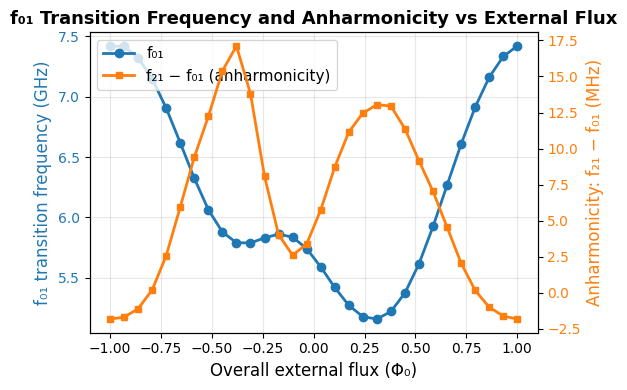

In [ ]:
# ----------------------------
# Flux sweep: overall external flux + different initial offsets per loop
# ----------------------------

N_potential = 4  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 3.333

EC = 0.1
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target
EJ = EL / EL_EJ_ratio

# Define different initial flux offsets for each loop (in units of Phi0)
phi_e_initial = np.array( [[0.3, 0.3], [0.7, -0.7], [-0.3, -0.3], [-0.4, -0.4]], dtype=float) # -0.7, +0.1, +0.7 
# Sweep range for overall external flux
phi_ext_sweep = np.linspace(-1, 1, 30)  # sweep flux in units of Phi0

n_levels_sweep = 3  # number of energy levels to compute at each flux point
N_fine = 1000
E_sweep = np.zeros((len(phi_ext_sweep), n_levels_sweep))
Ueff_fine_sweep_all = np.zeros((len(phi_ext_sweep), N_fine))  # store all potentials

print("Running flux sweep...")
for i, phi_ext in enumerate(phi_ext_sweep):
    # Set external flux for each branch: initial offset + overall flux
    phi_e_array_sweep = phi_e_initial + phi_ext/2
    
    # Compute effective potential
    result = full_analysis(
    phi_total_mag=2, 
    N_opt=40, 
    N_fine=N_fine, 
    phi_e_array=phi_e_array_sweep, 
    N_potential=N_potential, 
    EL=EL, 
    EJ=EJ, 
    EC=EC, 
    n_levels=n_levels_sweep, 
    order=5, 
    n_starts=1, 
    seed=0,
    options={"maxiter": 100, "gtol": 1e-7})
    
    Ueff_fine_sweep_all[i, :] = result["Ueff_fine"]  # store for later plotting
    E_sweep[i, :] = result["E_GHz"]  # store energy levels for this flux point
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{len(phi_ext_sweep)} flux points")

print("Flux sweep completed!\n")

# Plot f_01 transition frequency vs external flux
fig, ax = plt.subplots(figsize=(6, 4))

# Plot f_01 (ground to first excited) on left axis
f01 = E_sweep[:, 1] - E_sweep[:, 0]
ax.plot(phi_ext_sweep, f01, '-o', linewidth=2, markersize=6, color='C0', label='f₀₁')

ax.set_xlabel('Overall external flux (Φ₀)', fontsize=12)
ax.set_ylabel('f₀₁ transition frequency (GHz)', fontsize=12, color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_title('f₀₁ Transition Frequency and Anharmonicity vs External Flux', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for anharmonicity
ax2 = ax.twinx()

# Plot anharmonicity (f_21 - f_01) on right axis
f21 = E_sweep[:, 2] - E_sweep[:, 1]
anharmonicity = f21 - f01
ax2.plot(phi_ext_sweep, anharmonicity * 1e3, '-s', linewidth=2, markersize=5, color='C1', label='f₂₁ − f₀₁ (anharmonicity)')

ax2.set_ylabel('Anharmonicity: f₂₁ − f₀₁ (MHz)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()


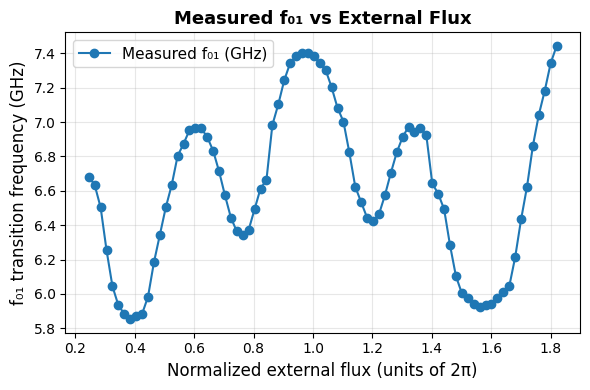

80 80


In [4]:
# =====================================================================
# Experimental data
# =====================================================================

flux_npi = -3.2     # raw flux value corresponding to -pi
flux_pi  = 2.65     # raw flux value corresponding to +pi
period   = flux_pi - flux_npi  # one full period in raw units

# Raw DC flux points (coil units)
DC_x = np.array([-2.4833, -2.425, -2.3667, -2.3083, -2.25, -2.1917, -2.1333,
        -2.0750, -2.0167, -1.9583, -1.90, -1.8417, -1.7833, -1.725,
        -1.6667, -1.6083, -1.55, -1.4917, -1.4333, -1.375, -1.3167,
         -1.2583, -1.2, -1.1417, -1.0833, -1.025, -0.9667, -0.9083,
        -0.85, -0.7917, -0.7333, -0.675, -0.6167, -0.5583, -0.5,
        -0.4417, -0.3833, -0.325, -0.2667, -0.2083, -0.15, -0.0917,
        -0.0333, 0.025, 0.0833, 0.1417, 0.2, 0.2583, 0.3167, 0.375,
        0.4333, 0.4917, 0.55, 0.6083, 0.6667, 0.725, 0.7833, 0.8417,
        0.9, 0.9583, 1.0167, 1.075, 1.1333, 1.1917, 1.25, 1.3083,
        1.3667, 1.425, 1.4833, 1.5417, 1.6, 1.6583, 1.7167, 1.775,
        1.8333, 1.8917, 1.95, 2.0083, 2.0667, 2.125])

# Normalize: map one period → 2 (same periodicity as cos(π φ_e) in simulation)
DC_x = (DC_x - flux_npi) / period * 2

# Measured coupler frequency (Hz); some are half-frequency × 2
peak_point = np.array([2.3e9, 2.25e9, 2.12e9, 1.87e9, 1.66e9, 1.55e9, 1.5e9,
              1.47e9, 1.49e9, 1.50e9, 1.60e9, 1.8e9, 1.96e9, 2.12e9,
              2.25e9, 2.42e9, 2.49e9, 2.57e9, 2.58e9, 2.58e9, 2.53e9,
              2.45e9, 2.33e9, 2.19e9, 2.06e9, 1.98e9, 1.96e9, 1.99e9,
              2.11e9, 2.23e9, 2.28e9, 1.3e9*2, 1.36e9*2, 1.43e9*2, 1.48e9*2,
              1.5e9*2, 1.51e9*2, 1.51e9*2, 1.50e9*2, 1.48e9*2, 1.46e9*2, 1.41e9*2,
              1.35e9*2, 2.62e9, 2.44e9, 2.24e9, 2.15e9, 2.06e9, 2.04e9, 2.08e9,
              2.19e9, 2.32e9, 2.44e9, 2.53e9, 2.59e9, 1.28e9*2, 2.58e9, 2.54e9,
              2.26e9, 2.2e9, 2.11e9, 1.9e9, 1.72e9, 1.62e9, 1.59e9, 1.56e9,
              1.54e9, 1.55e9, 1.56e9, 1.59e9, 1.63e9, 1.66e9, 1.83e9, 2.05e9,
              2.24e9, 2.48e9, 1.33e9*2, 1.4e9*2, 1.48e9*2, 1.53e9*2]) + 4383.375200045928e6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

plt.figure(figsize=(6, 4))
plt.plot(DC_x, f01_data_GHz, 'o-', label='Measured f₀₁ (GHz)', color='C0')
plt.xlabel('Normalized external flux (units of 2π)', fontsize=12)
plt.ylabel('f₀₁ transition frequency (GHz)', fontsize=12)
plt.title('Measured f₀₁ vs External Flux', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(len(DC_x), len(f01_data_GHz))

# differential_evolution

In [43]:
flux_npi = -3.2     # raw flux value corresponding to -pi
flux_pi  = 2.65     # raw flux value corresponding to +pi
period   = flux_pi - flux_npi  # one full period in raw units

# Raw DC flux points (coil units)
DC_x = np.array([-2.4833, -2.425, -2.3667, -2.3083, -2.25, -2.1917, -2.1333,
        -2.0750, -2.0167, -1.9583, -1.90, -1.8417, -1.7833, -1.725,
        -1.6667, -1.6083, -1.55, -1.4917, -1.4333, -1.375, -1.3167,
         -1.2583, -1.2, -1.1417, -1.0833, -1.025, -0.9667, -0.9083,
        -0.85, -0.7917, -0.7333, -0.675, -0.6167, -0.5583, -0.5,
        -0.4417, -0.3833, -0.325, -0.2667, -0.2083, -0.15, -0.0917,
        -0.0333, 0.025, 0.0833, 0.1417, 0.2, 0.2583, 0.3167, 0.375,
        0.4333, 0.4917, 0.55, 0.6083, 0.6667, 0.725, 0.7833, 0.8417,
        0.9, 0.9583, 1.0167, 1.075, 1.1333, 1.1917, 1.25, 1.3083,
        1.3667, 1.425, 1.4833, 1.5417, 1.6, 1.6583, 1.7167, 1.775,
        1.8333, 1.8917, 1.95, 2.0083, 2.0667, 2.125])

# Normalize: map one period → 2 (same periodicity as cos(π φ_e) in simulation)
DC_x = (DC_x - flux_npi) / period * 2

# Measured coupler frequency (Hz); some are half-frequency × 2
peak_point = np.array([2.3e9, 2.25e9, 2.12e9, 1.87e9, 1.66e9, 1.55e9, 1.5e9,
              1.47e9, 1.49e9, 1.50e9, 1.60e9, 1.8e9, 1.96e9, 2.12e9,
              2.25e9, 2.42e9, 2.49e9, 2.57e9, 2.58e9, 2.58e9, 2.53e9,
              2.45e9, 2.33e9, 2.19e9, 2.06e9, 1.98e9, 1.96e9, 1.99e9,
              2.11e9, 2.23e9, 2.28e9, 1.3e9*2, 1.36e9*2, 1.43e9*2, 1.48e9*2,
              1.5e9*2, 1.51e9*2, 1.51e9*2, 1.50e9*2, 1.48e9*2, 1.46e9*2, 1.41e9*2,
              1.35e9*2, 2.62e9, 2.44e9, 2.24e9, 2.15e9, 2.06e9, 2.04e9, 2.08e9,
              2.19e9, 2.32e9, 2.44e9, 2.53e9, 2.59e9, 1.28e9*2, 2.58e9, 2.54e9,
              2.26e9, 2.2e9, 2.11e9, 1.9e9, 1.72e9, 1.62e9, 1.59e9, 1.56e9,
              1.54e9, 1.55e9, 1.56e9, 1.59e9, 1.63e9, 1.66e9, 1.83e9, 2.05e9,
              2.24e9, 2.48e9, 1.33e9*2, 1.4e9*2, 1.48e9*2, 1.53e9*2]) + 4383.375200045928e6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

# =====================================================================
# Fixed circuit parameters
# =====================================================================

N_potential  = 3       # number of nonlinear branches
EC           = 0.126   # charging energy (GHz), fixed
EL_EJ_ratio  = 3.0     # EL / EJ ratio, fixed

# =====================================================================
# Simulation settings (reduced resolution for speed during fitting)
# Increase N_opt_fit / N_fine_fit for better accuracy at cost of runtime.
# =====================================================================

N_opt_fit    = 40      # coarse grid for Born-Oppenheimer minimization
N_fine_fit   = 400     # fine grid for diagonalization
n_levels_fit = 2       # number of energy levels to compute

# =====================================================================
# Cost function: sum of squared residuals between simulation and data
# =====================================================================

points = 2 # use every 2nd point to speed up fitting; adjust as needed for accuracy/runtime tradeoff
DC_x = DC_x[::points]
f01_data_GHz = f01_data_GHz[::points]

eval_count = [0]       # mutable counter for progress printing

def cost_function(params):
    """
    params = [phi_e_init[0,0], phi_e_init[0,1], phi_e_init[1,0], phi_e_init[1,1],
              phi_e_init[2,0], phi_e_init[2,1], EL]
    Returns sum of squared residuals (GHz^2) between simulated and measured f01.
    """
    phi_e_init = np.array(params[:N_potential * 2]).reshape(N_potential, 2)
    EL = params[N_potential * 2]
    
    EJ = EL / EL_EJ_ratio                         # Josephson energy from fixed ratio
    
    f01_sweep = np.zeros(len(DC_x))
    for j, phi_ext in enumerate(DC_x):
        # Each branch sees its own 2-flux offset + the global sweep flux
        phi_e_array = phi_e_init + phi_ext / 2 # divide by 2 because each branch sees half of the total external flux
        
        result = full_analysis(
            phi_total_mag=2,
            N_opt=N_opt_fit,
            N_fine=N_fine_fit,
            phi_e_array=phi_e_array,
            N_potential=N_potential,
            EL=EL, EJ=EJ, EC=EC,
            n_levels=n_levels_fit,
            order=5,
            n_starts=1,
            seed=0,
            options={"maxiter": 50, "gtol": 1e-6}
        )
        f01_sweep[j] = result['E_GHz'][1] - result['E_GHz'][0]
    
    # Least-squares residual
    residual = np.sum((f01_sweep - f01_data_GHz) ** 2)
    
    # Progress reporting
    eval_count[0] += 1
    if eval_count[0] % 5 == 0:
        rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
        print(
            f"  Eval {eval_count[0]:4d}:  residual = {residual:.4f} GHz^2   "
            f"RMS = {rms_MHz:.1f} MHz   EL = {EL:.2f}   "
            f"phi_e = [[{phi_e_init[0,0]:.3f}, {phi_e_init[0,1]:.3f}], "
            f"[{phi_e_init[1,0]:.3f}, {phi_e_init[1,1]:.3f}], "
            f"[{phi_e_init[2,0]:.3f}, {phi_e_init[2,1]:.3f}]]"
        )
    
    return residual

# =====================================================================
# Parameter bounds for global optimization
# =====================================================================

bounds = [
    (-0.5, 0.5),     # phi_e_init[0,0]  (units of Phi_0)
    (-0.5, 0.5),     # phi_e_init[0,1]
    (-0.5, 0.5),     # phi_e_init[1,0]
    (-0.5, 0.5),     # phi_e_init[1,1]
    (-0.5, 0.5),     # phi_e_init[2,0]
    (-0.5, 0.5),     # phi_e_init[2,1]
    (30.0, 300.0),   # EL (GHz) - broad range around expected ~130 GHz
]

# =====================================================================
# Run SHGO (global optimizer)
#
# SHGO can be slower but is systematic for low-dimensional problems
# =====================================================================

print("=" * 70)
print("Global least-squares fit: phi_e_init (6 params) + EL (1 param)")
print(f"  Fixed: EC = {EC} GHz, EL/EJ = {EL_EJ_ratio}")
print(f"  Data points: {len(DC_x)}")
print(f"  Simulation grid: N_opt={N_opt_fit}, N_fine={N_fine_fit}, N_sweep={len(DC_x)}")
print("=" * 70)

eval_count[0] = 0
t_start = time.time()

opt_result = differential_evolution(
    cost_function,
    bounds,
    maxiter=20,            # max number of generations
    popsize=15,             # individuals per parameter dimension
    tol=1e-4,               # relative convergence tolerance
    mutation=(0.5, 1.0),    # differential weight (dithered for robustness)
    recombination=0.7,      # crossover probability
    seed=0,                 # reproducibility
    disp=True,              # print generation-level progress
    polish=True,            # local refinement after DE converges
)

t_elapsed = time.time() - t_start

# =====================================================================
# Extract and display optimized parameters
# =====================================================================

phi_e_opt = opt_result.x[:N_potential * 2].reshape(N_potential, 2)
EL_opt    = opt_result.x[N_potential * 2]
EJ_opt    = EL_opt / EL_EJ_ratio

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)
print(
    f"  phi_e_init = [[{phi_e_opt[0,0]:.6f}, {phi_e_opt[0,1]:.6f}], "
    f"[{phi_e_opt[1,0]:.6f}, {phi_e_opt[1,1]:.6f}], "
    f"[{phi_e_opt[2,0]:.6f}, {phi_e_opt[2,1]:.6f}]] Phi_0"
 )
print(f"  EL = {EL_opt:.4f} GHz")
print(f"  EJ = {EJ_opt:.4f} GHz")
print(f"  EC = {EC} GHz (fixed)")
print(f"  EL/EJ = {EL_EJ_ratio} (fixed)")
print(f"  Residual = {opt_result.fun:.6f} GHz^2")
print(f"  RMS error = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
print(f"  Elapsed time = {t_elapsed:.1f} s ({t_elapsed/60:.1f} min)")
print(f"  Function evaluations = {opt_result.nfev}")
print(f"  Converged: {opt_result.success}  ({opt_result.message})")

Global least-squares fit: phi_e_init (6 params) + EL (1 param)
  Fixed: EC = 0.126 GHz, EL/EJ = 3.0
  Data points: 40
  Simulation grid: N_opt=40, N_fine=400, N_sweep=40
  Eval    5:  residual = 435.7587 GHz^2   RMS = 3300.6 MHz   EL = 30.00   phi_e = [[0.500, -0.500], [0.500, 0.500], [-0.500, -0.500]]
  Eval   10:  residual = 435.7587 GHz^2   RMS = 3300.6 MHz   EL = 30.00   phi_e = [[-0.500, 0.500], [-0.500, 0.500], [-0.500, 0.500]]
  Eval   15:  residual = 771.7826 GHz^2   RMS = 4392.6 MHz   EL = 300.00   phi_e = [[-0.500, 0.500], [0.500, 0.500], [-0.500, 0.500]]
  Eval   20:  residual = 435.7587 GHz^2   RMS = 3300.6 MHz   EL = 30.00   phi_e = [[-0.500, 0.500], [0.500, -0.500], [0.500, -0.500]]
  Eval   25:  residual = 435.7587 GHz^2   RMS = 3300.6 MHz   EL = 30.00   phi_e = [[0.500, 0.500], [0.500, -0.500], [0.500, 0.500]]
  Eval   30:  residual = 771.7826 GHz^2   RMS = 4392.6 MHz   EL = 300.00   phi_e = [[0.500, -0.500], [-0.500, -0.500], [0.500, 0.500]]
  Eval   35:  residual = 77

KeyboardInterrupt: 

In [1]:
# =====================================================================
# Plot fit result: re-run simulation at higher resolution with optimal params
# =====================================================================

# Higher-resolution simulation for a smooth plot
N_plot = 100  # number of flux sweep points for plotting
phi_ext_plot = np.linspace(DC_x.min() - 0.05, DC_x.max() + 0.05, N_plot)
f01_plot = np.zeros(N_plot)

print("Computing fit curve at higher resolution...")
for i, phi_ext in enumerate(phi_ext_plot):
    phi_e_array = phi_e_opt + phi_ext/2
    result = full_analysis(
        phi_total_mag=2,
        N_opt=40,           # full resolution for final plot
        N_fine=1000,
        phi_e_array=phi_e_array,
        N_potential=N_potential,
        EL=EL_opt, EJ=EJ_opt, EC=EC,
        n_levels=3,
        order=5, n_starts=1, seed=0,
        options={"maxiter": 100, "gtol": 1e-7}
    )
    f01_plot[i] = result['E_GHz'][1] - result['E_GHz'][0]
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N_plot} done")

print("Done.")

# ---- Plot experimental data vs best-fit simulation ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(DC_x, f01_data_GHz, 'o', markersize=6, color='C0',
        label='Experiment', zorder=3)
ax.plot(phi_ext_plot, f01_plot, '-', linewidth=2, color='C1',
        label='Best fit', zorder=2)

ax.set_xlabel('Normalized DC Flux (period units)', fontsize=12)
ax.set_ylabel('f₀₁ (GHz)', fontsize=12)
ax.set_title('Coupler Frequency: Experiment vs Fit', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate with fit parameters
textstr = (f"EL = {EL_opt:.2f} GHz\n"
           f"EJ = {EJ_opt:.2f} GHz\n"
           f"EC = {EC} GHz\n"
           f"RMS = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

# dual_annealing

In [50]:
flux_npi = -3.2     # raw flux value corresponding to -pi
flux_pi  = 2.65     # raw flux value corresponding to +pi
period   = flux_pi - flux_npi  # one full period in raw units

# Raw DC flux points (coil units)
DC_x = np.array([-2.4833, -2.425, -2.3667, -2.3083, -2.25, -2.1917, -2.1333,
        -2.0750, -2.0167, -1.9583, -1.90, -1.8417, -1.7833, -1.725,
        -1.6667, -1.6083, -1.55, -1.4917, -1.4333, -1.375, -1.3167,
         -1.2583, -1.2, -1.1417, -1.0833, -1.025, -0.9667, -0.9083,
        -0.85, -0.7917, -0.7333, -0.675, -0.6167, -0.5583, -0.5,
        -0.4417, -0.3833, -0.325, -0.2667, -0.2083, -0.15, -0.0917,
        -0.0333, 0.025, 0.0833, 0.1417, 0.2, 0.2583, 0.3167, 0.375,
        0.4333, 0.4917, 0.55, 0.6083, 0.6667, 0.725, 0.7833, 0.8417,
        0.9, 0.9583, 1.0167, 1.075, 1.1333, 1.1917, 1.25, 1.3083,
        1.3667, 1.425, 1.4833, 1.5417, 1.6, 1.6583, 1.7167, 1.775,
        1.8333, 1.8917, 1.95, 2.0083, 2.0667, 2.125])

# Normalize: map one period → 2 (same periodicity as cos(π φ_e) in simulation)
DC_x = (DC_x - flux_npi) / period * 2

# Measured coupler frequency (Hz); some are half-frequency × 2
peak_point = np.array([2.3e9, 2.25e9, 2.12e9, 1.87e9, 1.66e9, 1.55e9, 1.5e9,
              1.47e9, 1.49e9, 1.50e9, 1.60e9, 1.8e9, 1.96e9, 2.12e9,
              2.25e9, 2.42e9, 2.49e9, 2.57e9, 2.58e9, 2.58e9, 2.53e9,
              2.45e9, 2.33e9, 2.19e9, 2.06e9, 1.98e9, 1.96e9, 1.99e9,
              2.11e9, 2.23e9, 2.28e9, 1.3e9*2, 1.36e9*2, 1.43e9*2, 1.48e9*2,
              1.5e9*2, 1.51e9*2, 1.51e9*2, 1.50e9*2, 1.48e9*2, 1.46e9*2, 1.41e9*2,
              1.35e9*2, 2.62e9, 2.44e9, 2.24e9, 2.15e9, 2.06e9, 2.04e9, 2.08e9,
              2.19e9, 2.32e9, 2.44e9, 2.53e9, 2.59e9, 1.28e9*2, 2.58e9, 2.54e9,
              2.26e9, 2.2e9, 2.11e9, 1.9e9, 1.72e9, 1.62e9, 1.59e9, 1.56e9,
              1.54e9, 1.55e9, 1.56e9, 1.59e9, 1.63e9, 1.66e9, 1.83e9, 2.05e9,
              2.24e9, 2.48e9, 1.33e9*2, 1.4e9*2, 1.48e9*2, 1.53e9*2]) + 4383.375200045928e6

# Convert to GHz (same units as simulation output)
f01_data_GHz = peak_point / 1e9

# =====================================================================
# Fixed circuit parameters
# =====================================================================

N_potential  = 3       # number of nonlinear branches
EC           = 0.126   # charging energy (GHz), fixed
EL_EJ_ratio  = 3.0     # EL / EJ ratio, fixed

# =====================================================================
# Simulation settings (reduced resolution for speed during fitting)
# Increase N_opt_fit / N_fine_fit for better accuracy at cost of runtime.
# =====================================================================

N_opt_fit    = 20      # coarse grid for Born-Oppenheimer minimization
N_fine_fit   = 300     # fine grid for diagonalization
n_levels_fit = 2       # number of energy levels to compute

# =====================================================================
# Cost function: sum of squared residuals between simulation and data
# =====================================================================

points = 3 # use every 2nd point to speed up fitting; adjust as needed for accuracy/runtime tradeoff
DC_x = DC_x[::points]
f01_data_GHz = f01_data_GHz[::points]

eval_count = [0]       # mutable counter for progress printing

def cost_function(params):
    """
    params = [phi_e_init[0,0], phi_e_init[0,1], phi_e_init[1,0], phi_e_init[1,1],
              phi_e_init[2,0], phi_e_init[2,1], EL]
    Returns sum of squared residuals (GHz^2) between simulated and measured f01.
    """
    phi_e_init = np.array(params[:N_potential * 2]).reshape(N_potential, 2)
    EL = params[N_potential * 2]
    
    EJ = EL / EL_EJ_ratio                         # Josephson energy from fixed ratio
    
    f01_sweep = np.zeros(len(DC_x))
    for j, phi_ext in enumerate(DC_x):
        # Each branch sees its own 2-flux offset + the global sweep flux
        phi_e_array = phi_e_init + phi_ext / 2 # divide by 2 because each branch sees half of the total external flux
        
        result = full_analysis(
            phi_total_mag=2,
            N_opt=N_opt_fit,
            N_fine=N_fine_fit,
            phi_e_array=phi_e_array,
            N_potential=N_potential,
            EL=EL, EJ=EJ, EC=EC,
            n_levels=n_levels_fit,
            order=5,
            n_starts=1,
            seed=0,
            options={"maxiter": 50, "gtol": 1e-6}
        )
        f01_sweep[j] = result['E_GHz'][1] - result['E_GHz'][0]
    
    # Least-squares residual
    residual = np.sum((f01_sweep - f01_data_GHz) ** 2)
    
    # Progress reporting
    eval_count[0] += 1
    if eval_count[0] % 1 == 0:
        rms_MHz = np.sqrt(residual / len(DC_x)) * 1e3
        print(
            f"  Eval {eval_count[0]:4d}:  residual = {residual:.4f} GHz^2   "
            f"RMS = {rms_MHz:.1f} MHz   EL = {EL:.2f}   "
            f"phi_e = [[{phi_e_init[0,0]:.3f}, {phi_e_init[0,1]:.3f}], "
            f"[{phi_e_init[1,0]:.3f}, {phi_e_init[1,1]:.3f}], "
            f"[{phi_e_init[2,0]:.3f}, {phi_e_init[2,1]:.3f}]]"
        )
    
    return residual

# =====================================================================
# Parameter bounds for global optimization
# =====================================================================

bounds = [
    (-0.5, 0.49),     # phi_e_init[0,0]  (units of Phi_0)
    (-0.5, 0.49),     # phi_e_init[0,1]
    (-0.5, 0.49),     # phi_e_init[1,0]
    (-0.5, 0.49),     # phi_e_init[1,1]
    (-0.5, 0.49),     # phi_e_init[2,0]
    (-0.5, 0.49),     # phi_e_init[2,1]
    (30.0, 300.0),   # EL (GHz) - broad range around expected ~130 GHz
]

# =====================================================================
# Run dual_annealing (global optimizer)
#
# dual_annealing can be slower but is systematic for low-dimensional problems
# =====================================================================

print("=" * 70)
print("Global least-squares fit: phi_e_init (6 params) + EL (1 param)")
print(f"  Fixed: EC = {EC} GHz, EL/EJ = {EL_EJ_ratio}")
print(f"  Data points: {len(DC_x)}")
print(f"  Simulation grid: N_opt={N_opt_fit}, N_fine={N_fine_fit}, N_sweep={len(DC_x)}")
print("=" * 70)

eval_count[0] = 0
t_start = time.time()

opt_result = dual_annealing(
    cost_function,
    bounds,
    no_local_search=True)  # skip local refinement for speed; set to False to enable

t_elapsed = time.time() - t_start

# =====================================================================
# Extract and display optimized parameters
# =====================================================================

phi_e_opt = opt_result.x[:N_potential * 2].reshape(N_potential, 2)
EL_opt    = opt_result.x[N_potential * 2]
EJ_opt    = EL_opt / EL_EJ_ratio

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)
print(
    f"  phi_e_init = [[{phi_e_opt[0,0]:.6f}, {phi_e_opt[0,1]:.6f}], "
    f"[{phi_e_opt[1,0]:.6f}, {phi_e_opt[1,1]:.6f}], "
    f"[{phi_e_opt[2,0]:.6f}, {phi_e_opt[2,1]:.6f}]] Phi_0"
 )
print(f"  EL = {EL_opt:.4f} GHz")
print(f"  EJ = {EJ_opt:.4f} GHz")
print(f"  EC = {EC} GHz (fixed)")
print(f"  EL/EJ = {EL_EJ_ratio} (fixed)")
print(f"  Residual = {opt_result.fun:.6f} GHz^2")
print(f"  RMS error = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
print(f"  Elapsed time = {t_elapsed:.1f} s ({t_elapsed/60:.1f} min)")
print(f"  Function evaluations = {opt_result.nfev}")
print(f"  Converged: {opt_result.success}  ({opt_result.message})")

Global least-squares fit: phi_e_init (6 params) + EL (1 param)
  Fixed: EC = 0.126 GHz, EL/EJ = 3.0
  Data points: 27
  Simulation grid: N_opt=20, N_fine=300, N_sweep=27
  Eval    1:  residual = 298.5316 GHz^2   RMS = 3325.2 MHz   EL = 255.67   phi_e = [[-0.027, -0.375], [-0.378, 0.300], [-0.096, 0.346]]
  Eval    2:  residual = 38.8876 GHz^2   RMS = 1200.1 MHz   EL = 154.95   phi_e = [[0.145, -0.203], [-0.121, -0.432], [0.161, -0.387]]
  Eval    3:  residual = 76.7266 GHz^2   RMS = 1685.7 MHz   EL = 189.51   phi_e = [[0.137, 0.250], [-0.129, -0.441], [-0.375, 0.079]]
  Eval    4:  residual = 16.8754 GHz^2   RMS = 790.6 MHz   EL = 153.60   phi_e = [[-0.493, -0.379], [0.231, -0.080], [-0.015, -0.131]]
  Eval    5:  residual = 7.2450 GHz^2   RMS = 518.0 MHz   EL = 135.51   phi_e = [[-0.129, -0.016], [-0.396, 0.433], [-0.492, 0.232]]
  Eval    6:  residual = 11.9614 GHz^2   RMS = 665.6 MHz   EL = 129.44   phi_e = [[0.458, -0.418], [0.192, -0.491], [-0.426, -0.171]]
  Eval    7:  residual 

KeyboardInterrupt: 

In [ ]:
# =====================================================================
# Plot fit result: re-run simulation at higher resolution with optimal params
# =====================================================================

# Higher-resolution simulation for a smooth plot
N_plot = 100  # number of flux sweep points for plotting
phi_ext_plot = np.linspace(DC_x.min() - 0.05, DC_x.max() + 0.05, N_plot)
f01_plot = np.zeros(N_plot)

print("Computing fit curve at higher resolution...")
for i, phi_ext in enumerate(phi_ext_plot):
    phi_e_array = phi_e_opt + phi_ext/2
    result = full_analysis(
        phi_total_mag=2,
        N_opt=40,           # full resolution for final plot
        N_fine=1000,
        phi_e_array=phi_e_array,
        N_potential=N_potential,
        EL=EL_opt, EJ=EJ_opt, EC=EC,
        n_levels=3,
        order=5, n_starts=1, seed=0,
        options={"maxiter": 100, "gtol": 1e-7}
    )
    f01_plot[i] = result['E_GHz'][1] - result['E_GHz'][0]
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N_plot} done")

print("Done.")

# ---- Plot experimental data vs best-fit simulation ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(DC_x, f01_data_GHz, 'o', markersize=6, color='C0',
        label='Experiment', zorder=3)
ax.plot(phi_ext_plot, f01_plot, '-', linewidth=2, color='C1',
        label='Best fit', zorder=2)

ax.set_xlabel('Normalized DC Flux (period units)', fontsize=12)
ax.set_ylabel('f₀₁ (GHz)', fontsize=12)
ax.set_title('Coupler Frequency: Experiment vs Fit', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate with fit parameters
textstr = (f"EL = {EL_opt:.2f} GHz\n"
           f"EJ = {EJ_opt:.2f} GHz\n"
           f"EC = {EC} GHz\n"
           f"RMS = {np.sqrt(opt_result.fun / len(DC_x)) * 1e3:.1f} MHz")
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

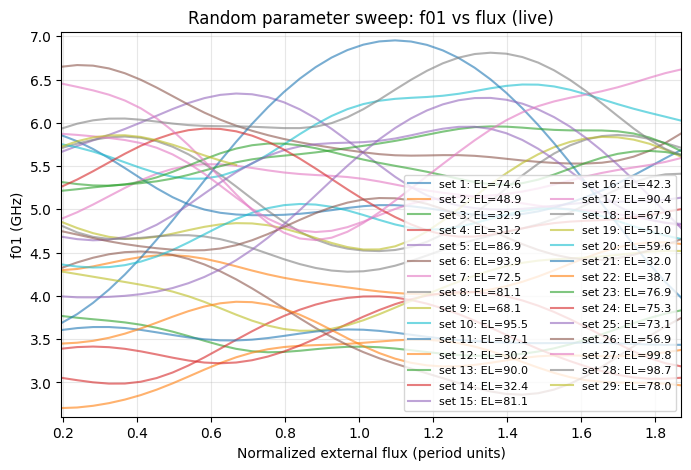

KeyboardInterrupt: 

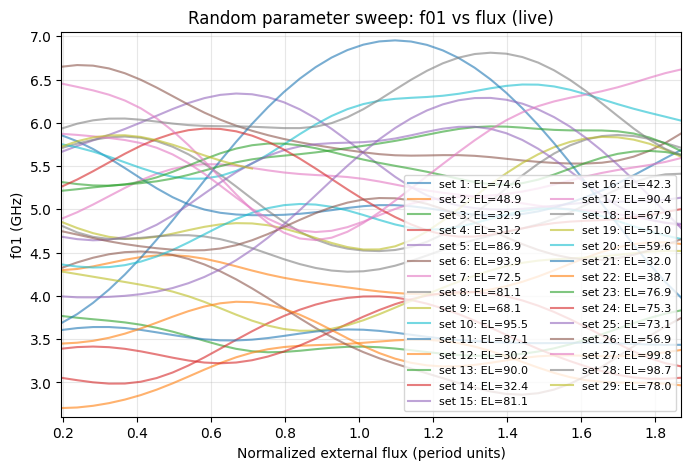

In [ ]:
# =====================================================================
# Random sweep: f01 vs flux for random EL and phi_e offsets
# =====================================================================

N_plot = 30  # number of random parameter sets to plot
N_flux = 40  # flux points per curve
seed = 0
rng = np.random.default_rng(seed)

# Parameter ranges
EL_min, EL_max = 30.0, 100.0
phi_min, phi_max = -0.5, 0.5  # offsets in units of Phi0

# Flux sweep range in normalized units (same as fit/plot range)
phi_ext_plot = np.linspace(DC_x.min() - 0.05, DC_x.max() + 0.05, N_flux)

# Fixed circuit parameters
N_potential = 3
EC = 0.126
EL_EJ_ratio = 3.0

# Simulation resolution (adjust for speed/accuracy)
N_opt = 30
N_fine = 1000
n_levels = 2

# Draw random samples
EL_samples = rng.uniform(EL_min, EL_max, size=N_plot)
phi_offsets = rng.uniform(phi_min, phi_max, size=(N_plot, N_potential, 2))

# Live plotting setup (use display handle for reliable updates in VS Code)
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("Normalized external flux (period units)")
ax.set_ylabel("f01 (GHz)")
ax.set_title("Random parameter sweep: f01 vs flux (live)")
ax.grid(True, alpha=0.3)
ax.set_xlim(phi_ext_plot.min(), phi_ext_plot.max())

y_min, y_max = np.inf, -np.inf
update_every = 1  # update plot every N flux points
lines = []

display_handle = display(fig, display_id=True)

for k in range(N_plot):
    EL = EL_samples[k]
    EJ = EL / EL_EJ_ratio
    f01_curve = np.zeros_like(phi_ext_plot)
    
    (line,) = ax.plot([], [], alpha=0.6, linewidth=1.5, label=f"set {k+1}: EL={EL:.1f}")
    lines.append(line)
    ax.legend(fontsize=8, ncol=2)
    
    for i, phi_ext in enumerate(phi_ext_plot):
        phi_e_array = phi_offsets[k] + phi_ext / 2.0
        result = full_analysis(
            phi_total_mag=2,
            N_opt=N_opt,
            N_fine=N_fine,
            phi_e_array=phi_e_array,
            N_potential=N_potential,
            EL=EL, EJ=EJ, EC=EC,
            n_levels=n_levels,
            order=5,
            n_starts=1,
            seed=0,
            options={"maxiter": 80, "gtol": 1e-6},
        )
        f01_curve[i] = result["E_GHz"][1] - result["E_GHz"][0]
        
        if i % update_every == 0 or i == len(phi_ext_plot) - 1:
            line.set_data(phi_ext_plot[: i + 1], f01_curve[: i + 1])
            y_min = min(y_min, np.min(f01_curve[: i + 1]))
            y_max = max(y_max, np.max(f01_curve[: i + 1]))
            ax.set_ylim(y_min - 0.1, y_max + 0.1)
            fig.canvas.draw_idle()
            display_handle.update(fig)

plt.show()